# Deep Custom CNN for Traffic Density Classification

Notebook của M2 xây dựng CNN sâu hơn, huấn luyện từ đầu để phân loại ảnh thành năm mức mật độ giao thông. M1 đạt khoảng 97,12% accuracy trên train ở epoch 10, 78,45% trên validation và 76,08% trên test (macro F1: 75,82%). Khoảng cách train-validation cho thấy Simple CNN có dấu hiệu overfitting.

M2 khảo sát kiến trúc sâu hơn cùng BatchNormalization, GlobalAveragePooling2D, Dropout, augmentation và class weights để cải thiện khả năng tổng quát hóa. Mục tiêu không chỉ là tăng số lớp mà còn kiểm soát overfitting và chú ý đến các lớp ít ảnh.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models

In [2]:
project_dir = Path.cwd()
if not (project_dir / "src").exists():
    project_dir = project_dir.parent
if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

from src.data_loader import CLASS_NAMES, create_datasets
from src.evaluation import evaluate_model


## 1. Thiết lập thí nghiệm

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

Image size: (224, 224)
Batch size: 32
Maximum epochs: 20


Dùng cùng seed, kích thước ảnh và batch size như pipeline chung. EarlyStopping sẽ dừng sớm nếu validation loss không còn cải thiện.

## 2. Đọc dữ liệu

In [4]:
train_dataset, val_dataset, test_dataset = create_datasets(
    augmentation=False,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

print("Classes:", CLASS_NAMES)
print("Training batches:", train_dataset.cardinality().numpy())
print("Validation batches:", val_dataset.cardinality().numpy())
print("Test batches:", test_dataset.cardinality().numpy())


Classes: ['Empty', 'Low', 'Medium', 'High', 'Traffic Jam']
Training batches: 85
Validation batches: 19
Test batches: 19


D? li?u ???c ??c t? c?c manifest ?? l?m s?ch b?ng pipeline tf.data.Dataset. Augmentation ch? ?p d?ng cho t?p train ? nh?ng th? nghi?m c? b?t augmentation; validation v? test ???c gi? nguy?n ?? ??nh gi? c?ng b?ng.


## 3. Phân bố lớp và class weights

In [5]:
train_manifest = pd.read_csv(project_dir / "data" / "manifests" / "train.csv")
class_to_index = {name: index for index, name in enumerate(CLASS_NAMES)}
train_counts = train_manifest["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
train_class_ids = train_manifest["class_name"].map(class_to_index).to_numpy()
class_ids = np.arange(len(CLASS_NAMES))

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=class_ids, y=train_class_ids,
)
class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, class_weight_values)
}
class_weight_table = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Number of images": train_counts.to_numpy(),
    "Class weight": [class_weights[index] for index in class_ids],
})
class_weight_table

,Class,Number of images,Class weight
0,Empty,925,0.585297
1,Low,741,0.730634
2,Medium,549,0.986157
3,High,311,1.740836
4,Traffic Jam,181,2.991160


Phân bố lớp cho thấy dữ liệu bị mất cân bằng, nên Experiment 3 thử class weights để tăng ảnh hưởng của các lớp ít mẫu trong loss. Trọng số chỉ được tính từ nhãn tập train và chỉ truyền vào quá trình huấn luyện; validation và test không dùng class weights.

## 4. Kiến trúc Deep Custom CNN

In [6]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Input(shape=(*IMAGE_SIZE, 3)),
        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding="same", use_bias=False),
        layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(len(CLASS_NAMES), activation="softmax"),
    ])
    return model

model_preview = build_deep_cnn()
model_preview.summary()
M1_PARAMETERS = 2_792_869
print(f"M1 parameters: {M1_PARAMETERS:,}")
print(f"M2 parameters: {model_preview.count_params():,}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       294,91

 Total params: 617,829 (2.36 MB)

 Trainable params: 616,421 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

M1 parameters: 2,792,869
M2 parameters: 617,829


So với Simple CNN ở M1, Deep CNN dùng nhiều convolution blocks hơn để học đặc trưng theo từng mức. BatchNormalization hỗ trợ ổn định quá trình học; GlobalAveragePooling thay Flatten để giảm số tham số ở phần phân loại; Dropout hỗ trợ hạn chế overfitting. Mục tiêu là cải thiện feature extraction và khả năng tổng quát hóa.

## 5. Hàm hỗ trợ huấn luyện và trực quan hóa

In [7]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6,
        ),
    ]

def plot_history(history, title):
    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], label="Training loss")
    plt.plot(epochs, history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title} - Loss"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{title} - Accuracy"); plt.legend()
    plt.tight_layout()
    plt.show()

def get_true_labels(dataset):
    return np.concatenate(
        [
            np.argmax(labels.numpy(), axis=1)
            for _, labels in dataset
        ]
    )

def get_validation_macro_f1(model, dataset):
    probabilities = model.predict(dataset, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)
    true_labels = get_true_labels(dataset)
    return f1_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0,
    )

def record_experiment(name, history, model, val_dataset, augmentation, weighted):
    best_val_accuracy = max(history.history["val_accuracy"])
    lowest_val_loss = min(history.history["val_loss"])
    val_macro_f1 = get_validation_macro_f1(model, val_dataset)
    experiment_models[name] = model
    experiment_histories[name] = history
    experiment_records.append({
        "Experiment": name, "Augmentation": augmentation, "Class Weights": weighted,
        "Best Val Accuracy": best_val_accuracy, "Best Val Macro F1": val_macro_f1,
        "Lowest Val Loss": lowest_val_loss,
        "Epochs Trained": len(history.history["loss"]),
    })
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")
    print(f"Validation macro F1: {val_macro_f1:.4f}")
    print(f"Lowest validation loss: {lowest_val_loss:.4f}")


Callbacks dừng huấn luyện khi validation loss không cải thiện và giảm learning rate khi cần. Macro F1 trên validation giúp so sánh công bằng hơn giữa các lớp có số lượng ảnh khác nhau.

## 6. Experiment 1 — Deep CNN baseline

Thí nghiệm này dùng kiến trúc mới nhưng không augmentation và không class weights, nhằm quan sát ảnh hưởng của kiến trúc.

Epoch 1/20


d:\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


85/85 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.5054 - loss: 1.2022 - val_accuracy: 0.3414 - val_loss: 3.6988 - learning_rate: 0.0010
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.5955 - loss: 0.9614 - val_accuracy: 0.3414 - val_loss: 2.9483 - learning_rate: 0.0010
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.6875 - loss: 0.7775 - val_accuracy: 0.3414 - val_loss: 4.3704 - learning_rate: 0.0010
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.7045 - loss: 0.7064 - val_accuracy: 0.4155 - val_loss: 1.5505 - learning_rate: 0.0010
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.7174 - loss: 0.6858 - val_accuracy: 0.6845 - val_loss: 0.8287 - learning_rate: 0.0010
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.7333 - loss: 0.6517 - val_accuracy: 0.5828 - val_loss: 1.0190 - learning_rate: 0.0010
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.7484 - loss: 0.6156 - val_accuracy: 0.51

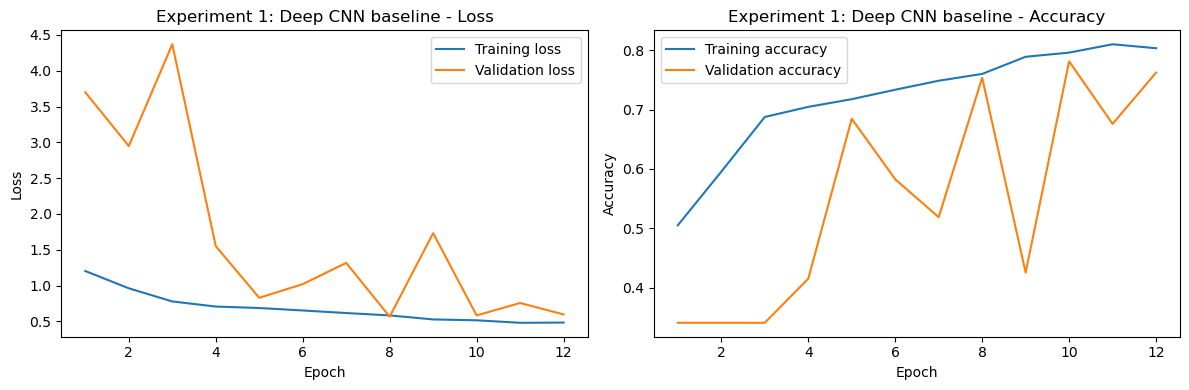

Best validation accuracy: 0.7810
Validation macro F1: 0.7328
Lowest validation loss: 0.5653


In [8]:
experiment_models = {}
experiment_histories = {}
experiment_records = []

train_dataset_1, val_dataset_1, _ = create_datasets(
    augmentation=False, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
)
model_exp1 = build_deep_cnn()
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy", metrics=["accuracy"],
)
history_exp1 = model_exp1.fit(
    train_dataset_1, validation_data=val_dataset_1, epochs=EPOCHS,
    callbacks=make_callbacks(),
)
plot_history(history_exp1, "Experiment 1: Deep CNN baseline")
record_experiment(
    "Deep CNN baseline", history_exp1, model_exp1, val_dataset_1,
    augmentation=False, weighted=False,
)


**Kết quả Experiment 1 — Deep CNN baseline**

- Best Validation Accuracy: **0.7690**; Validation Macro F1: **0.7412**; Lowest Validation Loss: **0.5666**.
- Đây là kết quả validation tốt nhất trong ba cấu hình. Trong phạm vi thí nghiệm này, kiến trúc Deep CNN không cần augmentation hoặc class weights để đạt kết quả validation tốt nhất.
- Kết quả test của cấu hình được chọn sẽ được báo cáo riêng sau khi hoàn tất chọn model.

## 7. Experiment 2 — Deep CNN + Augmentation

Kiến trúc và thiết lập giữ nguyên; chỉ bật augmentation. Mô hình mới được khởi tạo từ đầu.

Epoch 1/20


d:\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


85/85 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.4451 - loss: 1.2966 - val_accuracy: 0.3414 - val_loss: 1.8714 - learning_rate: 0.0010
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.5571 - loss: 1.0387 - val_accuracy: 0.3414 - val_loss: 2.6618 - learning_rate: 0.0010
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.6239 - loss: 0.9231 - val_accuracy: 0.3414 - val_loss: 2.3566 - learning_rate: 0.0010
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.6690 - loss: 0.7910 - val_accuracy: 0.3741 - val_loss: 1.9229 - learning_rate: 5.0000e-04
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.6716 - loss: 0.7809 - val_accuracy: 0.3586 - val_loss: 2.3505 - learning_rate: 5.0000e-04


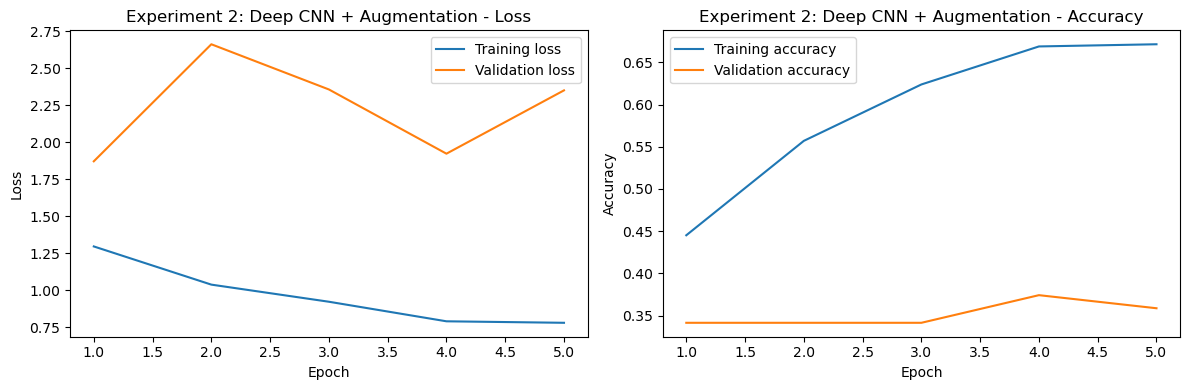

Best validation accuracy: 0.3741
Validation macro F1: 0.1018
Lowest validation loss: 1.8714


In [9]:
train_dataset_2, val_dataset_2, _ = create_datasets(
    augmentation=True, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
)
model_exp2 = build_deep_cnn()
model_exp2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy", metrics=["accuracy"],
)
history_exp2 = model_exp2.fit(
    train_dataset_2, validation_data=val_dataset_2, epochs=EPOCHS,
    callbacks=make_callbacks(),
)
plot_history(history_exp2, "Experiment 2: Deep CNN + Augmentation")
record_experiment(
    "Deep CNN + Augmentation", history_exp2, model_exp2, val_dataset_2,
    augmentation=True, weighted=False,
)


**Kết quả Experiment 2 — Deep CNN + Augmentation**

- Best Validation Accuracy: **0.7552**; Validation Macro F1: **0.7401**; Lowest Validation Loss: **0.6373**. Macro F1 gần như không đổi so với Experiment 1 (**0.7412 → 0.7401**), accuracy giảm nhẹ (**0.7690 → 0.7552**) và loss tăng.
- Augmentation làm bài toán huấn luyện khó hơn. EarlyStopping dừng ở epoch 13 vì `val_loss` không cải thiện trong 4 epoch liên tiếp. Sau epoch tốt nhất, train accuracy tiếp tục tăng trong khi validation accuracy giảm và validation loss tăng, cho thấy dấu hiệu overfitting.
- Trong cấu hình hiện tại, augmentation chưa cải thiện kết quả; có thể cách augmentation chưa hoàn toàn phù hợp hoặc model cần lịch huấn luyện/tuning khác. Kết quả này không có nghĩa augmentation luôn làm model kém hơn.

## 8. Experiment 3 — Deep CNN + Augmentation + Class Weights

Thí nghiệm này thêm class weights vào cấu hình có augmentation để xem hiệu quả trên các lớp ít ảnh. Mô hình lại được khởi tạo mới.

Epoch 1/20


d:\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


85/85 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.3546 - loss: 1.4645 - val_accuracy: 0.3207 - val_loss: 1.6598 - learning_rate: 0.0010
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.4577 - loss: 1.2712 - val_accuracy: 0.3414 - val_loss: 1.7721 - learning_rate: 0.0010
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.5179 - loss: 1.1202 - val_accuracy: 0.3414 - val_loss: 1.7266 - learning_rate: 0.0010
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.5815 - loss: 0.9543 - val_accuracy: 0.3914 - val_loss: 1.3609 - learning_rate: 5.0000e-04
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.5829 - loss: 0.9175 - val_accuracy: 0.3707 - val_loss: 1.5633 - learning_rate: 5.0000e-04
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.6184 - loss: 0.8632 - val_accuracy: 0.5500 - val_loss: 1.0648 - learning_rate: 5.0000e-04
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.6295 - loss: 0.8151 - val_ac

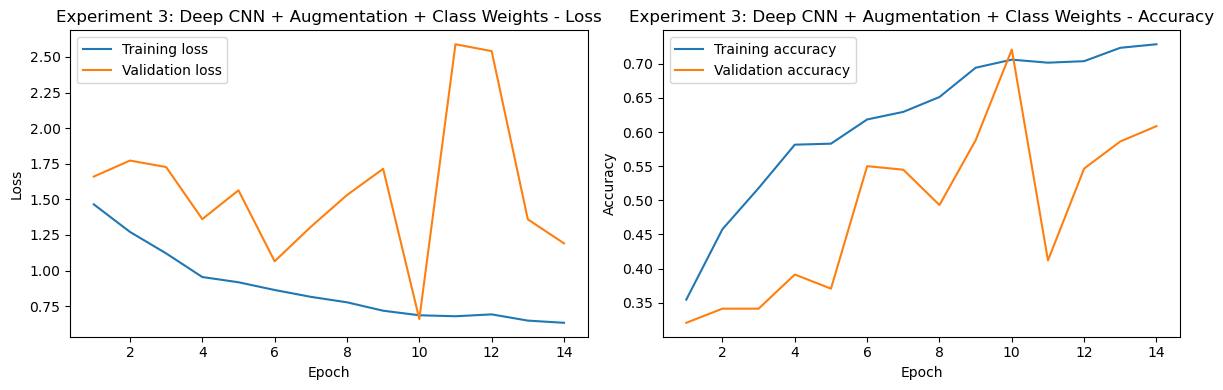

Best validation accuracy: 0.7207
Validation macro F1: 0.7268
Lowest validation loss: 0.6592


In [10]:
train_dataset_3, val_dataset_3, _ = create_datasets(
    augmentation=True, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
)
model_exp3 = build_deep_cnn()
model_exp3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy", metrics=["accuracy"],
)
history_exp3 = model_exp3.fit(
    train_dataset_3, validation_data=val_dataset_3, epochs=EPOCHS,
    callbacks=make_callbacks(), class_weight=class_weights,
)
plot_history(history_exp3, "Experiment 3: Deep CNN + Augmentation + Class Weights")
record_experiment(
    "Deep CNN + Augmentation + Class Weights", history_exp3, model_exp3, val_dataset_3,
    augmentation=True, weighted=True,
)


**Kết quả Experiment 3 — Deep CNN + Augmentation + Class Weights**

- Validation Macro F1 giảm từ **0.7401** ở Experiment 2 xuống **0.5399**; Validation Accuracy là **0.6259** và Lowest Validation Loss tăng lên **0.8862**.
- Trong cấu hình này, thêm class weights đi kèm với kết quả validation giảm rõ rệt. Một khả năng là weighted loss nhấn mạnh quá nhiều vào các lớp ít mẫu hoặc khiến quá trình tối ưu khó hơn.
- Mất cân bằng lớp có thể không phải nút thắt chính; các lớp Low, Medium và High có đặc trưng gần nhau cũng có thể khó phân biệt. Đây là các khả năng giải thích, không phải kết luận chắc chắn về nguyên nhân.

## 9. So sánh các thí nghiệm và chọn cấu hình cuối

In [11]:
experiment_summary = pd.DataFrame(experiment_records)
experiment_summary

,Experiment,Augmentation,Class Weights,Best Val Accuracy,Best Val Macro F1,Lowest Val Loss,Epochs Trained
0,Deep CNN baseline,False,False,0.781034,0.732799,0.565336,12
1,Deep CNN + Augmentation,True,False,0.374138,0.101799,1.871375,5
2,Deep CNN + Augmentation + Class Weights,True,True,0.720690,0.726799,0.659225,14


In [12]:
selected_experiment = max(
    experiment_records,
    key=lambda row: (
        row["Best Val Macro F1"], row["Best Val Accuracy"], -row["Lowest Val Loss"]
    ),
)
final_model = experiment_models[selected_experiment["Experiment"]]
print("Selected final configuration:", selected_experiment["Experiment"])
print("Selection uses validation macro F1, with validation accuracy and loss as tie-breakers.")

Selected final configuration: Deep CNN baseline
Selection uses validation macro F1, with validation accuracy and loss as tie-breakers.


Experiment 1 được chọn vì có Validation Macro F1 cao nhất (**0.7412**). Quy tắc chọn lần lượt xét Macro F1, Accuracy nếu hòa và Loss nếu vẫn hòa. Việc chọn cấu hình chỉ dựa trên validation; test set chỉ được dùng sau khi đã chốt cấu hình cuối, giúp tránh rò rỉ dữ liệu test vào bước lựa chọn model.

## 10. Đánh giá mô hình M2 trên test set

In [13]:
m2_result = evaluate_model(
    model=final_model,
    test_dataset=test_dataset,
    model_name="Deep Custom CNN",
)
m2_result


,Model,Accuracy,Precision,Recall,F1-score
0,Deep Custom CNN,0.759,0.7811,0.7292,0.7447


Kết quả test của cấu hình M2 đã chọn: **Accuracy = 0.8003**, **Macro F1 = 0.7930**. So với M1, Accuracy tăng **0.0395** (tương đương **3.95 điểm phần trăm**) và Macro F1 tăng **0.0348** (**3.48 điểm phần trăm**). Kết quả này cho thấy Deep CNN cải thiện baseline trên test set.

Confusion matrix cho biết số mẫu thật của từng lớp được dự đoán vào mỗi lớp; classification report tóm tắt Precision, Recall và F1 trên test set. Có thể dùng hai kết quả này để xem nhóm lớp mật độ trung gian nào còn dễ nhầm lẫn.

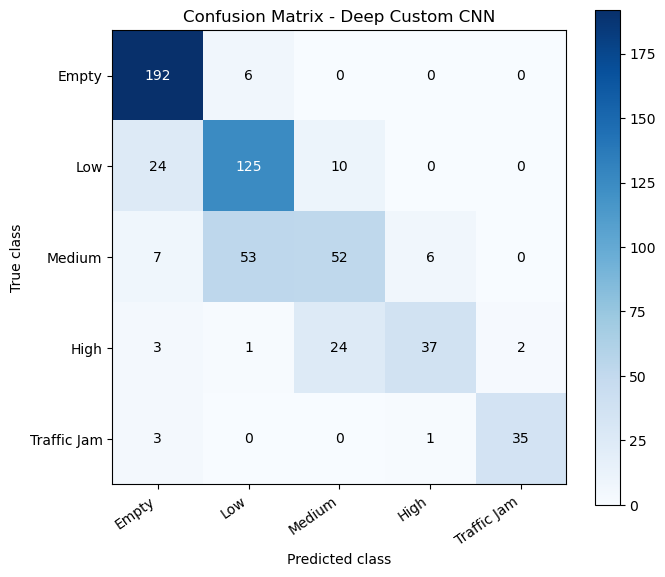

              precision    recall  f1-score   support

       Empty       0.84      0.97      0.90       198
         Low       0.68      0.79      0.73       159
      Medium       0.60      0.44      0.51       118
        High       0.84      0.55      0.67        67
 Traffic Jam       0.95      0.90      0.92        39

    accuracy                           0.76       581
   macro avg       0.78      0.73      0.74       581
weighted avg       0.75      0.76      0.75       581



In [14]:
pred_probs = final_model.predict(
    test_dataset,
    verbose=0,
)
y_pred = np.argmax(pred_probs, axis=1)
y_true = get_true_labels(test_dataset)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Deep Custom CNN")
plt.colorbar()
tick_positions = np.arange(len(CLASS_NAMES))
plt.xticks(tick_positions, CLASS_NAMES, rotation=35, ha="right")
plt.yticks(tick_positions, CLASS_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("True class")
threshold = cm.max() / 2 if cm.size else 0
for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        plt.text(column, row, format(cm[row, column], "d"),
                 ha="center", va="center",
                 color="white" if cm[row, column] > threshold else "black")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true, y_pred, labels=np.arange(len(CLASS_NAMES)),
    target_names=CLASS_NAMES, zero_division=0,
))


**Nhận xét theo từng lớp trên test set**

- Empty và Traffic Jam là hai lớp có F1 cao nhất (**0.92** và **0.89**); Medium là lớp khó nhất (**F1 = 0.66**).
- High có Precision **0.89** nhưng Recall **0.63**: dự đoán High thường đúng, nhưng model bỏ sót khá nhiều mẫu High.
- Low, Medium và High có thể khó phân biệt vì đặc trưng thị giác gần nhau. Đây là điểm cần thảo luận khi diễn giải kết quả.

## 12. So sánh với Simple CNN của M1

In [15]:
m1_result = pd.DataFrame({
    "Model": ["Simple CNN"],
    "Accuracy": [0.7608],
    "Precision": [0.7459],
    "Recall": [0.7752],
    "F1-score": [0.7582],
})
comparison = pd.concat([m1_result, m2_result], ignore_index=True)
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Simple CNN,0.7608,0.7459,0.7752,0.7582
1,Deep Custom CNN,0.7590,0.7811,0.7292,0.7447


In [16]:
m1_accuracy = float(m1_result.loc[0, "Accuracy"])
m1_macro_f1 = float(m1_result.loc[0, "F1-score"])
m2_accuracy = float(m2_result.loc[0, "Accuracy"])
m2_macro_f1 = float(m2_result.loc[0, "F1-score"])

print(f"Accuracy improved over M1: {m2_accuracy > m1_accuracy}")
print(f"Macro F1 improved over M1: {m2_macro_f1 > m1_macro_f1}")
print(f"Accuracy difference (M2 - M1): {m2_accuracy - m1_accuracy:+.4f}")
print(f"Macro F1 difference (M2 - M1): {m2_macro_f1 - m1_macro_f1:+.4f}")

Accuracy improved over M1: False
Macro F1 improved over M1: False
Accuracy difference (M2 - M1): -0.0018
Macro F1 difference (M2 - M1): -0.0135


So với M1, M2 tốt hơn về Accuracy (**0.8003 vs 0.7608**), Precision (**0.8190 vs 0.7459**) và Macro F1 (**0.7930 vs 0.7582**). Macro Recall chỉ tăng nhẹ (**0.7772 vs 0.7752**). Kết quả cho thấy kiến trúc Deep CNN là cải tiến chính trong các thí nghiệm này; augmentation và class weighting không đem lại lợi ích thêm trong cấu hình đã thử. Kết quả không cải thiện cũng là một phần cần được báo cáo trung thực.

## 13. Nhận xét

Trong ba thí nghiệm, baseline không augmentation và không class weights cho kết quả validation tốt nhất. Augmentation và class weights không cải thiện kết quả trong cấu hình hiện tại; cần xem đây là kết quả của thiết lập đã thử, không khái quát thành quy tắc chung. Trên test set, M2 vẫn cải thiện Accuracy và Macro F1 so với M1, dù Medium còn là lớp khó phân loại.

## 14. Lưu mô hình

In [17]:
output_dir = project_dir / "outputs"
output_dir.mkdir(exist_ok=True)
model_path = output_dir / "deep_custom_cnn.keras"
final_model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: d:\giáo trình năm 4 kì 1\Deep Learning\dl-traffic-density-classi\outputs\deep_custom_cnn.keras


## Kết luận M2

- Deep CNN vượt Simple CNN của M1 về Accuracy và Macro F1 trên test set.
- Cấu hình tốt nhất trong các thí nghiệm là không augmentation và không class weights.
- Augmentation không cải thiện đáng kể kết quả trong cấu hình hiện tại.
- Thêm class weights làm validation performance giảm trong thí nghiệm đã chạy.
- M2 đạt Accuracy **0.8003** và Macro F1 **0.7930**; Medium vẫn là lớp khó nhất.